In [1]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import arviz as az

ret = pd.read_csv("../data_and_results/returns.csv", index_col=0, parse_dates=True)["^GSPC"]
garch = pd.read_csv("../data_and_results/garch_output.csv", index_col=0, parse_dates=True)

with open("../data_and_results/sv_posterior.pkl", "rb") as f:
    idata = pickle.load(f)

# Extract h samples: shape (chain, draw, time)
h_samples = idata.posterior["h"].values
sigma_sv = np.exp(h_samples / 2.0)                  # SV conditional volatility paths
sigma_sv_mean = sigma_sv.mean(axis=(0, 1))          # posterior mean
sigma_sv_lo = np.quantile(sigma_sv, 0.025, axis=(0, 1))
sigma_sv_hi = np.quantile(sigma_sv, 0.975, axis=(0, 1))

dates = ret.index

Plot A — posterior SV vs |r_t|:

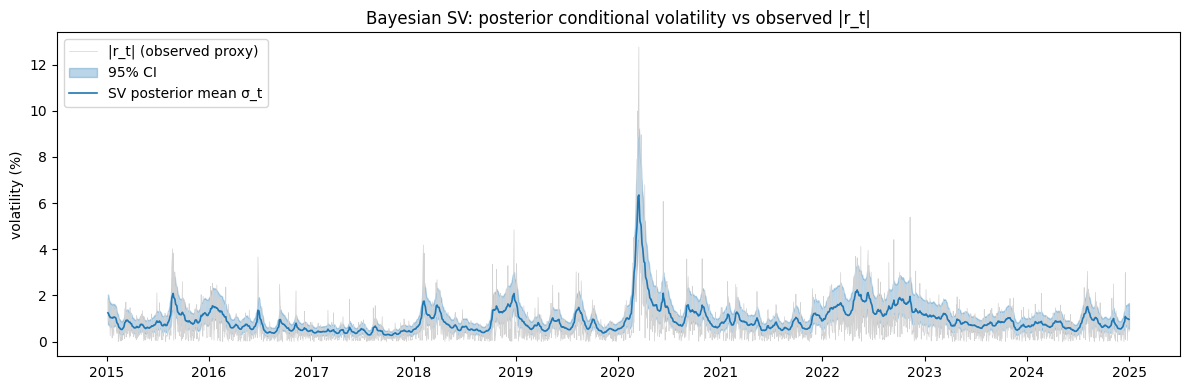

In [2]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(dates, np.abs(ret), color="lightgray", lw=0.5, label="|r_t| (observed proxy)")
ax.fill_between(dates, sigma_sv_lo, sigma_sv_hi, alpha=0.3, color="C0", label="95% CI")
ax.plot(dates, sigma_sv_mean, color="C0", lw=1.2, label="SV posterior mean σ_t")
ax.set_ylabel("volatility (%)")
ax.set_title("Bayesian SV: posterior conditional volatility vs observed |r_t|")
ax.legend(loc="upper left")
plt.tight_layout()
plt.savefig("../figures/plot_A_sv_vs_proxy.png", dpi=150)
plt.show()

Plot B — SV vs GARCH:

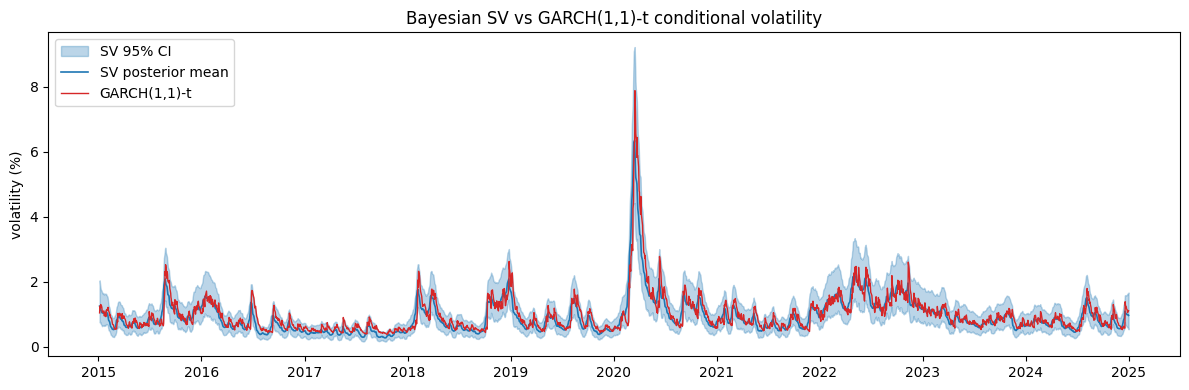

In [3]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(dates, sigma_sv_lo, sigma_sv_hi, alpha=0.3, color="C0", label="SV 95% CI")
ax.plot(dates, sigma_sv_mean, color="C0", lw=1.2, label="SV posterior mean")
ax.plot(garch.index, garch["sigma_garch"], color="C3", lw=1.0, label="GARCH(1,1)-t")
ax.set_ylabel("volatility (%)")
ax.set_title("Bayesian SV vs GARCH(1,1)-t conditional volatility")
ax.legend(loc="upper left")
plt.tight_layout()
plt.savefig("../figures/plot_B_sv_vs_garch.png", dpi=150)
plt.show()

Plot C — parameter posteriors with summary table:

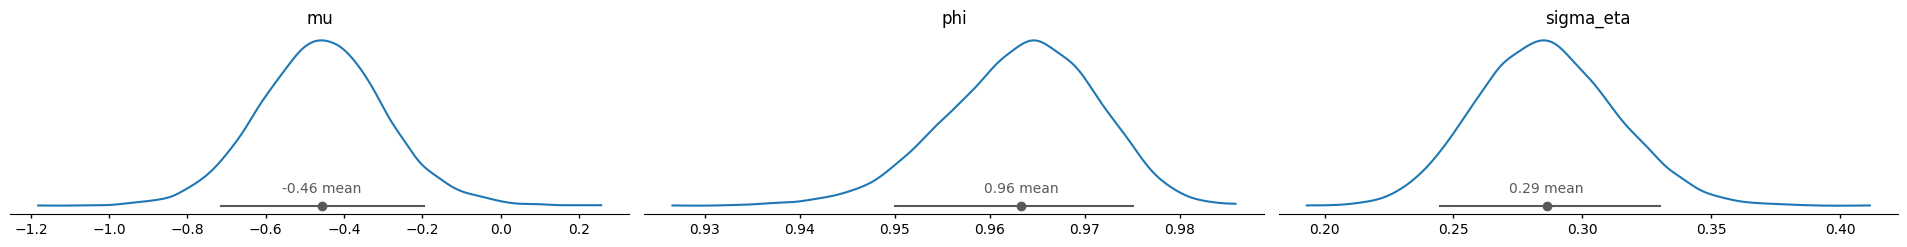

             mean      sd eti89_lb eti89_ub  ess_bulk  ess_tail r_hat  \
mu         -0.457   0.163    -0.71     -0.2      5165      4910  1.00   
phi        0.9633  0.0079     0.95     0.98      2360      3623  1.00   
sigma_eta   0.286  0.0269     0.24     0.33      1912      3220  1.00   

          mcse_mean  mcse_sd  
mu           0.0023   0.0018  
phi         0.00016  0.00012  
sigma_eta   0.00061  0.00044  


In [4]:
az.plot_dist(idata, var_names=["mu", "phi", "sigma_eta"])
plt.tight_layout()
plt.savefig("../figures/plot_C_param_posteriors.png", dpi=150)
plt.show()

summary = az.summary(idata, var_names=["mu", "phi", "sigma_eta"])
print(summary)
summary.to_csv("../data_and_results/sv_param_summary.csv")